# Analisis Dataset Amazon Berkeley Objects (ABO) untuk Text-to-Image Retrieval

## Kelompok 1

1. I Made Wardana (2482421006)  
2. I Kadek Aldy Oka Ardita (2482421005)  
3. I Gede Putu Wahyu Brianala Genta Putra (2482421007)  
4. Ni Putu Arisya Agustiana (2482421004)  
5. Putri Prema Paramitha (2482421012)

# 1.1 Latar Belakang

Pesatnya pertumbuhan industri *e-commerce* global, seperti yang terlihat pada platform berskala besar seperti **Amazon**, telah menghasilkan ledakan data produk yang sangat masif. Dalam ekosistem ini, kemampuan pengguna untuk menemukan produk yang spesifik (seperti produk *fashion*, furnitur, atau aksesori elektronik) sangat bergantung pada efisiensi sistem informasi yang digunakan.

### Masalah Pencarian Berbasis Teks pada Domain Produk
Secara tradisional, pencarian produk mengandalkan deskripsi tekstual. Namun, dalam domain produk yang memiliki variasi visual tinggi (misalnya kategori **SHOES** atau **HOME_FURNITURE_AND_DECOR** dalam dataset *Amazon Berkeley Objects*), teks sering kali gagal merepresentasikan karakteristik fisik produk secara utuh. Masalah utama yang sering muncul antara lain:
* **Subjektivitas Deskripsi:** Penjual mungkin memberikan nama produk yang tidak konsisten atau terlalu singkat. Teks metadata seringkali mengandung *noise* berupa kata kunci SEO yang tidak selalu relevan dengan fitur visual produk yang sebenarnya.
* **Informasi Visual yang Hilang:** Detail seperti corak, bentuk lekukan, atau tekstur bahan sangat sulit dituangkan sepenuhnya ke dalam deretan kata-kata. Hal ini menyebabkan kesenjangan informasi antara apa yang dibayangkan pengguna dan apa yang tertulis di database.

### Keterbatasan Keyword-Based Retrieval
Pencarian berbasis kata kunci (*keyword*) memiliki keterbatasan fundamental dalam memahami konteks dan semantik:
1. **Ketidakmampuan Menangani Sinonim:** Sistem tradisional sering kali gagal menghubungkan kata "alas kaki" dengan "sepatu" jika tidak ada pemetaan manual.
2. **Masalah Ambiguitas:** Satu kata kunci bisa merujuk pada banyak jenis barang yang berbeda secara visual, sehingga menurunkan *precision* (ketepatan) hasil pencarian.
3. **Ketergantungan pada Metadata:** Jika metadata produk tidak lengkap, mengandung *typo*, atau memiliki kesalahan label (seperti teks menyebutkan 'Red' namun gambar menunjukkan warna 'Black'), produk tersebut menjadi tidak dapat ditemukan atau tidak akurat bagi pengguna.

### Kebutuhan Pendekatan Multimodal
Melihat keterbatasan di atas, diperlukan transisi dari pencarian berbasis teks murni menuju **Pendekatan Multimodal (Text-to-Image Retrieval)**. Pendekatan ini, yang diimplementasikan menggunakan dataset **Amazon Berkeley Objects (ABO)**, mengintegrasikan dua modalitas data yang berbeda: **teks (listing metadata)** dan **citra (visual embeddings)**.

Kebutuhan akan pendekatan multimodal ini didorong oleh beberapa faktor:
* **Representasi Semantik Terpadu:** Dengan menggunakan model seperti CLIP, sistem dapat memetakan teks dan gambar ke dalam satu ruang vektor (*shared embedding space*). Hal ini memungkinkan pencarian didasarkan pada kemiripan makna semantik, bukan sekadar kecocokan karakter huruf.
* **Peningkatan Akurasi:** Melalui analisis skor *similarity*, sistem dapat menyaring pasangan data yang berkualitas rendah atau *mismatch*, memastikan bahwa hasil pencarian benar-benar sesuai secara visual dengan deskripsi yang diberikan.
* **Fleksibilitas Pencarian:** Pengguna dapat melakukan pencarian dengan bahasa alami yang lebih luwes, di mana sistem memahami konsep visual (seperti perbedaan antara 'Sneakers' dan 'Loafers') meskipun keduanya berada dalam kategori besar yang sama.


## 1.2 Rumusan Masalah

Berdasarkan latar belakang yang telah diuraikan, rumusan masalah dalam penelitian ini adalah sebagai berikut:
1. Bagaimana karakteristik dan kualitas dataset multimodal Amazon Berkeley Objects (ABO) dalam mendukung pengembangan sistem pencarian produk visual?
2. Bagaimana mengukur tingkat kesamaan (*similarity*) secara semantik antara representasi kueri teks (deskripsi produk) dan representasi gambar secara efektif?
3. Bagaimana merancang arsitektur sistem *text-to-image retrieval* berbasis *embedding* yang mampu memberikan hasil pencarian dengan akurasi dan relevansi tinggi?

## 1.3 Tujuan

Sejalan dengan rumusan masalah di atas, tujuan utama dari penelitian ini adalah:
1. Melakukan analisis komprehensif (*Exploratory Data Analysis*) terhadap dataset multimodal untuk memahami distribusi, struktur, dan kualitas pasangan teks serta citra produk.
2. Merancang dan memodelkan arsitektur sistem *text-to-image retrieval* menggunakan pendekatan berbasis vektor (*shared embedding space*) untuk memfasilitasi pencarian lintas modalitas.
3. Menyusun rencana tahapan teknis dan implementasi sistem pencarian berbasis *embedding* yang siap dievaluasi performanya.

## 1.4 Batasan Penelitian

Agar analisis dan perancangan sistem lebih terfokus, penelitian ini menetapkan beberapa batasan sebagai berikut:
1. **Fokus Retreival Searah (Text-to-Image):** Sistem yang dirancang difokuskan secara spesifik pada pencarian gambar produk menggunakan kueri teks (*text-to-image retrieval*), dan tidak mencakup pencarian sebaliknya (*image-to-text* atau *image-to-image*).
2. **Pembatasan Skala Dataset:** Mengingat keterbatasan sumber daya komputasi dan untuk efisiensi analisis, eksperimen tidak menggunakan keseluruhan dataset. Evaluasi *retrieval* akan dibatasi menggunakan sub-sampel dataset (berkisar 780 data pada kategori shoes.
3. **Penggunaan Model Pre-Trained (Tanpa *Training*):** Penelitian ini menggunakan model ekstraksi fitur yang sudah dilatih sebelumnya (*pre-trained model*, seperti CLIP). Tidak ada tahapan *fine-tuning* atau pelatihan ulang arsitektur model dari awal (*training from scratch*). Proses utamanya hanya meliputi pengekstraksian *embedding* dan perhitungan *similarity*.

# 2. DESKRIPSI DATASET

## 2.1 Sumber Dataset

Dataset yang digunakan dalam analisis ini bersumber dari koleksi data objek produk nyata yang dipublikasikan secara terbuka untuk keperluan riset komputer visi dan pemrosesan bahasa alami.
*   **Nama Dataset:** Amazon Berkeley Objects (ABO) Dataset
*   **Ketersediaan/Link Repositori:** Dataset resmi dapat diakses melalui dokumentasi ABO dan diunduh secara *hosting* melalui infrastruktur Amazon S3 (misal: `https://amazon-berkeley-objects.s3.amazonaws.com/`).


In [ ]:
# 0. Persiapan folder
!mkdir -p dataset/listings dataset/images/metadata dataset/images/small

# 1. Download & ekstrak metadata listings
!wget https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-listings.tar -O abo-listings.tar
!tar -xvf abo-listings.tar -C dataset/listings

# 2. Download & ekstrak images (small)
!wget https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar -O abo-images-small.tar
!tar -xvf abo-images-small.tar -C dataset/images

# 3. Download image metadata
!wget https://amazon-berkeley-objects.s3.amazonaws.com/images/metadata/images.csv.gz -P dataset/images/metadata/

Output streaming akan dipotong hingga 5000 baris terakhir.
images/small/de/de139f62.jpg
images/small/de/de29aca6.jpg
images/small/de/de3a69f9.jpg
images/small/de/debd544b.jpg
images/small/de/def1c6fa.jpg
images/small/de/de9f78b3.jpg
images/small/de/dea862ca.jpg
images/small/de/de2c8a98.jpg
images/small/de/de02b860.jpg
images/small/de/de3df885.jpg
images/small/de/de716a2a.jpg
images/small/de/de83f5ce.jpg
images/small/de/de45d158.jpg
images/small/de/de06ecb3.jpg
images/small/de/def81caf.jpg
images/small/de/de40d9a3.jpg
images/small/de/de066f92.jpg
images/small/de/de6b5b17.jpg
images/small/de/de01c750.jpg
images/small/de/de6079d1.jpg
images/small/de/de388fd2.jpg
images/small/de/deec717f.jpg
images/small/de/de613085.jpg
images/small/de/de93dd84.jpg
images/small/de/dec4464e.jpg
images/small/de/de062410.jpg
images/small/de/de091dd8.jpg
images/small/de/deab7ba1.jpg
images/small/de/dee79b4c.jpg
images/small/de/ded56a84.jpg
images/small/de/de37d588.jpg
images/small/de/de4fdddc.jpg
images/small/

## 2.3 Struktur Data
Berikut adalah struktur data yang telah diekstrak:

In [ ]:
import pandas as pd
import gzip
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 1. Load Listings Metadata
print("Memuat metadata produk...")
data = []
# Path standar setelah ekstraksi tar biasanya: listings/metadata/listings_0.json.gz
# Kita pastikan path mengarah ke lokasi yang benar
listing_path = 'dataset/listings/listings/metadata/listings_0.json.gz'

if not os.path.exists(listing_path):
    # Mencoba path alternatif jika struktur folder berbeda
    listing_path = 'dataset/listings/metadata/listings_0.json.gz'

try:
    with gzip.open(listing_path, 'rt') as f:
        for i, line in enumerate(f):
            if i >= 30000:
                break
            try:
                item = json.loads(line.strip())
                data.append(item)
            except:
                continue
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di {listing_path}. Pastikan proses download dan ekstrak di cell sebelumnya selesai.")

df_listings = pd.DataFrame(data)

# Fungsi untuk mengekstrak teks bahasa Inggris dari list of dicts
def extract_en_text(item_list):
    if isinstance(item_list, list):
        for entry in item_list:
            if isinstance(entry, dict) and entry.get('language_tag', '').startswith('en_'):
                return entry.get('value', '')
        if len(item_list) > 0 and isinstance(item_list[0], dict):
            return item_list[0].get('value', '')
    return None

if not df_listings.empty:
    df_listings['item_name_en'] = df_listings['item_name'].apply(extract_en_text)
    df_listings['category'] = df_listings['product_type'].apply(lambda x: x[0]['value'] if isinstance(x, list) and len(x) > 0 else None)

# 2. Load Images Metadata
print("Memuat metadata gambar...")
df_images = pd.read_csv('dataset/images/metadata/images.csv.gz')

# 3. Merge data
df_merged = pd.merge(df_listings, df_images, left_on='main_image_id', right_on='image_id', how='inner')

# Buat path relatif untuk gambar
df_merged['image_path'] = 'dataset/images/' + df_merged['path']

# Buat tabel akhir yang sesuai permintaan
df_final = df_merged[['item_id', 'image_path', 'item_name_en', 'category']].rename(columns={
    'item_id': 'id',
    'item_name_en': 'text'
})

df_final.head()

Memuat metadata produk...
Memuat metadata gambar...


,id,image_path,text,category
0,B06X9STHNG,dataset/images/8c/8ccb5859.jpg,Amazon-merk - vinden. Dames Leder Gesloten Tee...,SHOES
1,B07P8ML82R,dataset/images/9f/9f76d27b.jpg,"22"" Bottom Mount Drawer Slides, White Powder C...",HARDWARE
2,B07H9GMYXS,dataset/images/66/665cc994.jpg,"AmazonBasics PETG 3D Printer Filament, 1.75mm,...",MECHANICAL_COMPONENTS
3,B07CTPR73M,dataset/images/b4/b4f9d0cc.jpg,"Stone & Beam Stone Brown Swatch, 25020039-01",SOFA
4,B01MTEI8M6,dataset/images/2b/2b1c2516.jpg,The Fix Amazon Brand Women's French Floral Emb...,SHOES


## 2.4 Kualitas Data
Analisis:
- **Missing Data:** Memeriksa baris yang tidak memiliki gambar atau teks.
- **Duplikasi:** Memeriksa duplikasi pada pasangan text dan gambar.
- **Teks Tidak Sesuai Gambar (Mismatch Awal):** Mendeteksi entri yang memiliki anomali atau tidak konsisten.

In [ ]:
# Analisis Kualitas Data
missing_data = df_final.isnull().sum()
print("Missing Data:\n", missing_data)

# Drop missing data
df_final = df_final.dropna(subset=['text', 'image_path', 'category'])

duplicate_data = df_final.duplicated(subset=['text', 'image_path']).sum()
print("\nDuplikasi Pasangan Teks-Gambar:", duplicate_data)

# Filter out duplicates
df_final = df_final.drop_duplicates(subset=['text', 'image_path'])

# Distribusi Kategori
top_categories = df_final['category'].value_counts().head(10)
print("\nTop 10 Kategori Produk:")
print(top_categories)


Missing Data:
 id            0
image_path    0
text          0
category      0
dtype: int64

Duplikasi Pasangan Teks-Gambar: 0

Top 10 Kategori Produk:
category
CELLULAR_PHONE_CASE         4099
SHOES                        760
GROCERY                      407
HOME                         343
HOME_BED_AND_BATH            199
HOME_FURNITURE_AND_DECOR     154
CHAIR                        125
FINERING                     120
BOOT                         115
SANDAL                       107
Name: count, dtype: int64


# 3. EXPLORATORY DATA ANALYSIS (EDA)
## 3.1 Analisis Teks
- **Distribusi panjang teks:** Mengukur jumlah kata dari deskripsi produk.
- **Kata dominan:** Kata-kata yang paling sering muncul di kategori Shoes.

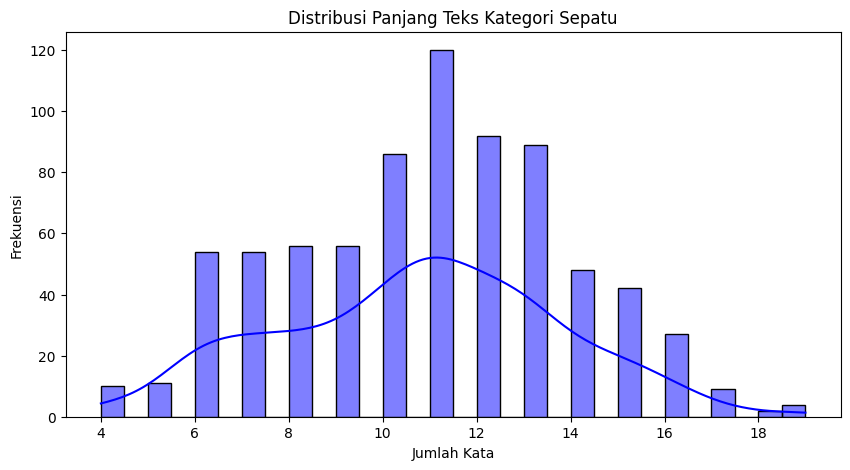

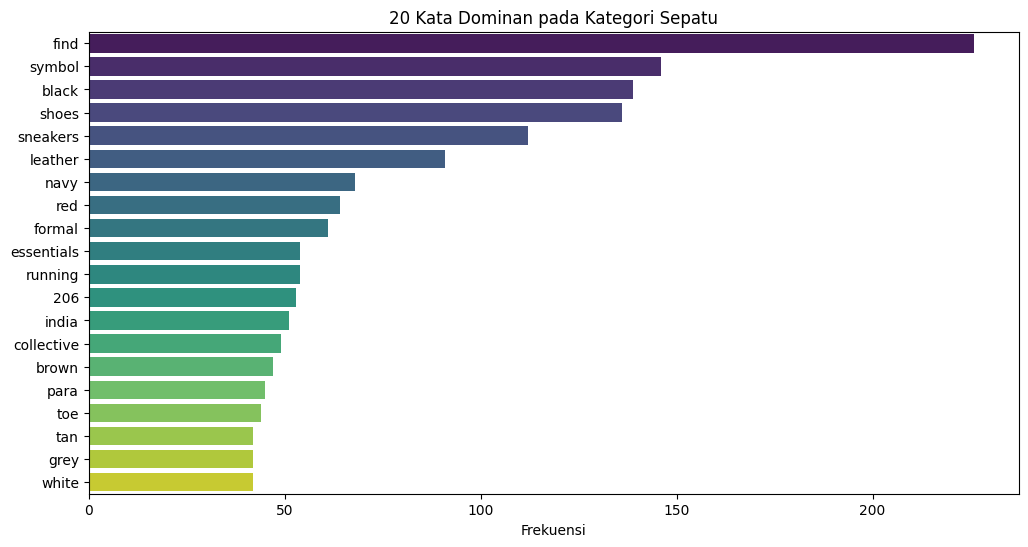

In [ ]:
from collections import Counter
import re

# Panjang teks
df_shoes['text_len'] = df_shoes['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_shoes['text_len'], bins=30, kde=True, color='blue')
plt.title('Distribusi Panjang Teks Kategori Sepatu')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

# Kata Dominan
def get_words(text):
    text = str(text).lower()
    words = re.findall(r'\w+', text)
    stopwords = {'for', 'and', 'with', 'the', 'women', 'men', 'in', 'of', 'a', 'to', 'brand', 'amazon'}
    return [w for w in words if w not in stopwords and len(w) > 2]

all_words = []
df_shoes['text'].apply(lambda x: all_words.extend(get_words(x)))

word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('20 Kata Dominan pada Kategori Sepatu')
plt.xlabel('Frekuensi')
plt.show()

## 3.2 Analisis Citra
- **Ukuran gambar:** Meninjau resolusi rata-rata dari dataset.
- **Variasi visual:** Melihat pola dari gambar (background, pose).

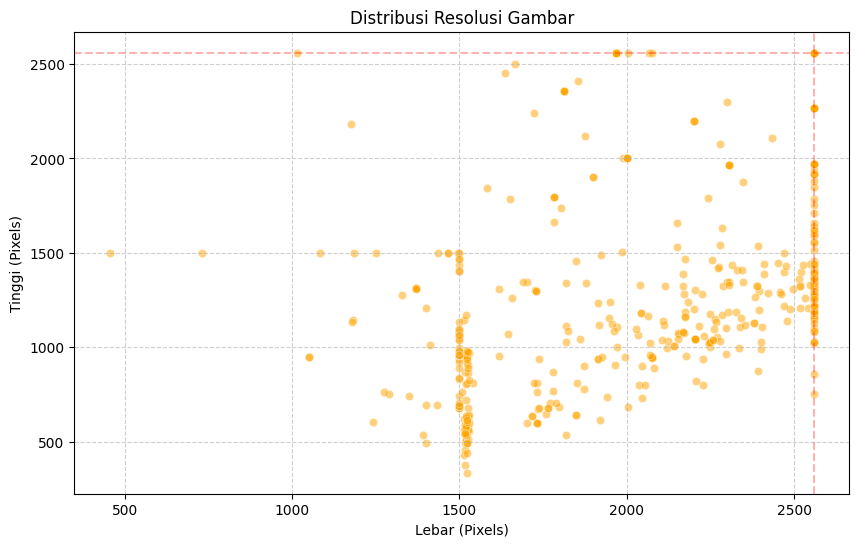

**Resolusi Terbanyak:** 1969 x 2560 px

In [ ]:
from IPython.display import Markdown, display

# Memperbaiki join agar path sesuai
df_images_adj = df_images.copy()
df_images_adj['full_path'] = 'dataset/images/' + df_images_adj['path']

# Filter data kategori terpilih
df_filtered_meta = pd.merge(df_shoes, df_images_adj, left_on='image_path', right_on='full_path', how='inner')

if not df_filtered_meta.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='width', y='height', data=df_filtered_meta, alpha=0.5, color='orange')

    plt.axvline(2560, color='red', linestyle='--', alpha=0.3)
    plt.axhline(2560, color='red', linestyle='--', alpha=0.3)

    plt.title(f'Distribusi Resolusi Gambar')
    plt.xlabel('Lebar (Pixels)')
    plt.ylabel('Tinggi (Pixels)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Menampilkan angka saja
    common_res = df_filtered_meta.groupby(['width', 'height']).size().idxmax()
    display(Markdown(f"**Resolusi Terbanyak:** {common_res[0]} x {common_res[1]} px"))
else:
    print("Data tidak ditemukan.")

## 3.3 Analisis Hubungan Teks–Citra
Tampilkan minimal 10 contoh teks dan citra, dan analisis apakah teks benar-benar menggambarkan gambar.:

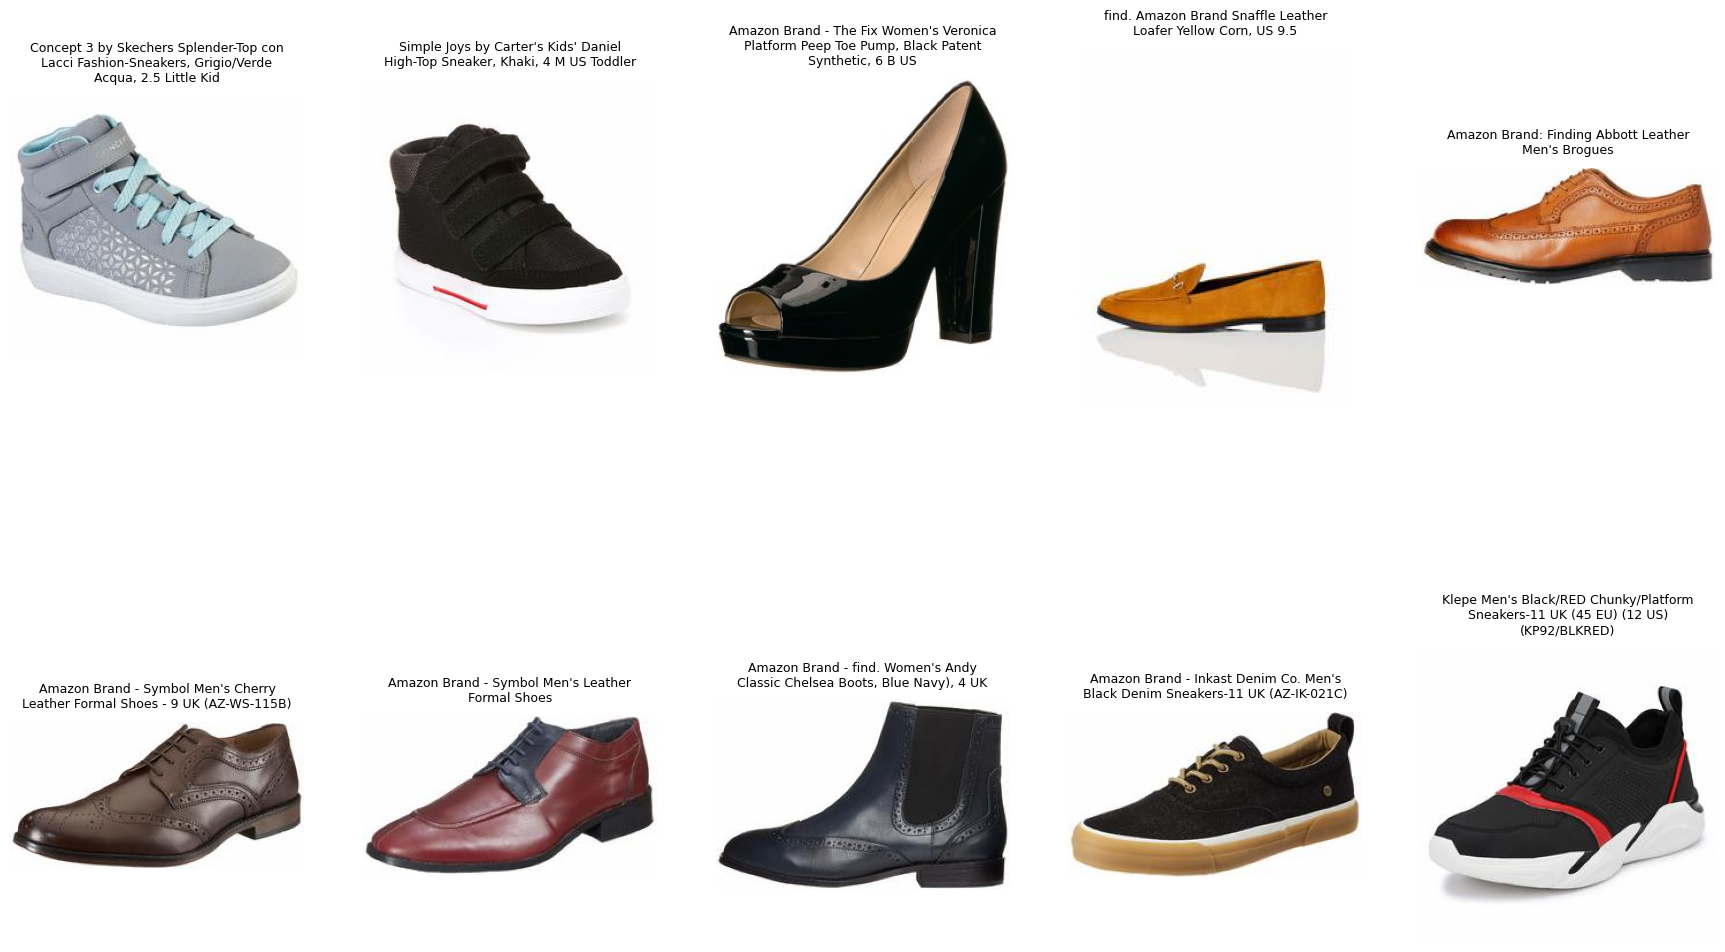

In [ ]:
import random
import os
import glob
import textwrap

# Mencari satu file gambar
found_files = glob.glob('**/images/small/**/*.jpg', recursive=True)
if found_files:
    # Ambil base directory
    actual_base = found_files[0].split('images/small/')[0] + 'images/small/'

    # Bersihkan image_path di dataframe
    df_shoes['image_path'] = df_shoes['image_path'].apply(lambda x: actual_base + x.split('/')[-2] + '/' + x.split('/')[-1])

# Filterg file
df_shoes_exists = df_shoes[df_shoes['image_path'].apply(lambda x: os.path.exists(x))]

# Tampilkan 10 contoh acak
sample_shoes = df_shoes_exists.sample(min(10, len(df_shoes_exists)), random_state=42)

if len(sample_shoes) > 0:
    # Menambah ukuran figure dan rasio tinggi agar teks tidak bertumpuk
    fig, axes = plt.subplots(2, 5, figsize=(22, 12))
    axes = axes.flatten()

    for i, (_, row) in enumerate(sample_shoes.iterrows()):
        ax = axes[i]
        try:
            img = Image.open(row['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'Error Loading', ha='center', va='center')

        # Menggunakan textwrap agar caption tidak kepotong ke samping
        caption = "\n".join(textwrap.wrap(str(row['text']), width=40))
        ax.set_title(caption, fontsize=9, pad=10)
        ax.axis('off')

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    # Menambah hspace (horizontal space) antar baris
    plt.subplots_adjust(hspace=0.6)
    plt.show()
else:
    print(f'Peringatan: Tidak ada file valid.')


# 4. ANALISIS MASALAH RETRIEVAL (Eksplorasi dengan Model CLIP)

## 4.1 Keyword-based Retrieval


## 4.2 Masalah Ambiguitas


## 4.3 Kebutuhan Embedding


Berikut adalah eksplorasi pembuktian masalah mismatch dan kemampuan deteksi CLIP.

Loading CLIP Model (openai/clip-vit-base-patch32)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Menghitung embedding untuk 500 pasangan Teks-Gambar...

--- DETEKSI 10 MISMATCH TERENDAH OLEH CLIP ---


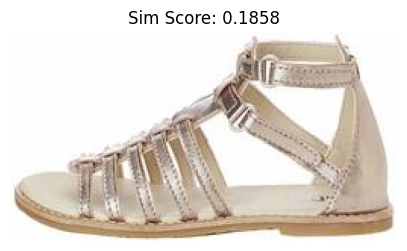

Teks: Marque Amazon - RED WAGON Spartiates Effet Métallisé Fille



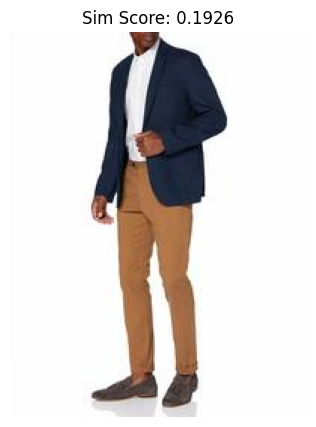

Teks: find. Mens^Men's Leather Loafer, Grey Anthracite, Womens 12



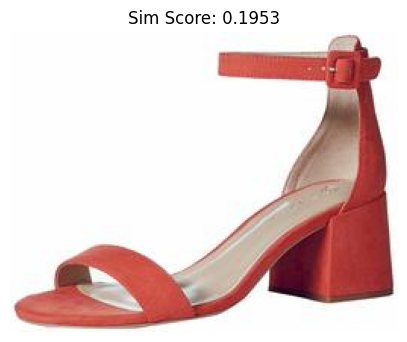

Teks: Marchio Amazon -  Lyon Sandali con cinturino, tacco a blocco di The Drop



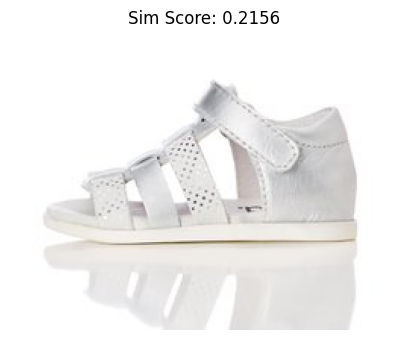

Teks: RED WAGON Sandales Métalisées à Scratch Fille, Argent (Silver), 19 EU



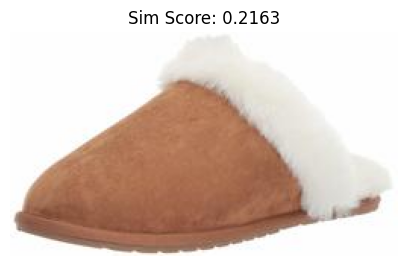

Teks: [Amazon Essentials] レディース スカッフスリッパ, チェスナット, 10



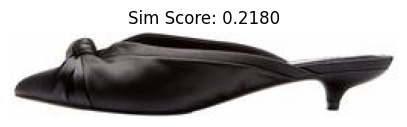

Teks: find. Womens 118al1885 Mules



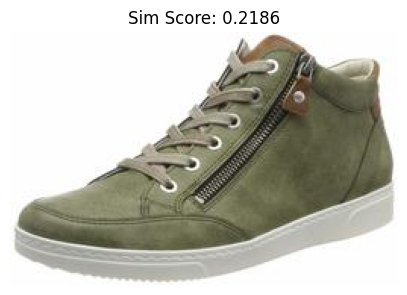

Teks: find. Amazon Brand Jute Sole Soft Leather Loafers, Beige Taupe, US 8.5



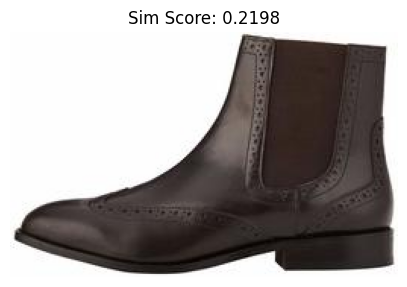

Teks: Marchio Amazon - find. Donna Stivali chelsea



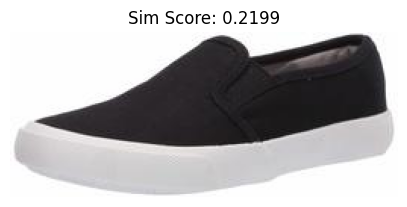

Teks: Amazon Essentials Boys’ Pete



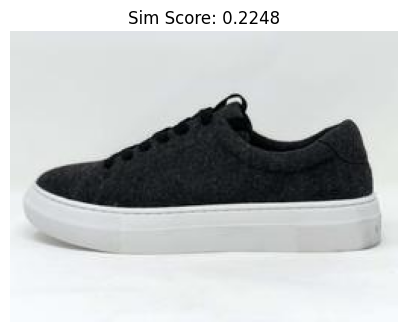

Teks: Amazon Brand - 206 Collective Men's Morris Sneaker, White, 10.5 B US



In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
import numpy as np
import matplotlib.pyplot as plt

print("Loading CLIP Model (openai/clip-vit-base-patch32)...")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Pastikan kita menggunakan dataframe yang memiliki file valid
df_to_sample = df_shoes_exists if 'df_shoes_exists' in globals() else df_shoes

# Ambil 50 sampel gambar & teks Sepatu untuk eksplorasi cepat
sample_clip = df_to_sample.sample(min(500, len(df_to_sample)), random_state=10).reset_index(drop=True)

images = []
texts = []
valid_indices = []

for idx, row in sample_clip.iterrows():
    try:
        img = Image.open(row['image_path']).convert('RGB')
        images.append(img)
        texts.append(row['text'])
        valid_indices.append(idx)
    except:
        continue

sample_clip = sample_clip.iloc[valid_indices].reset_index(drop=True)

if len(images) > 0:
    print(f"Menghitung embedding untuk {len(images)} pasangan Teks-Gambar...")
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True, truncation=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    image_embeds = outputs.image_embeds.cpu().numpy()
    text_embeds = outputs.text_embeds.cpu().numpy()

    # Normalisasi vektor untuk Cosine Similarity
    image_embeds = image_embeds / np.linalg.norm(image_embeds, axis=1, keepdims=True)
    text_embeds = text_embeds / np.linalg.norm(text_embeds, axis=1, keepdims=True)

    # Hitung similarity di diagonal
    similarities = np.sum(image_embeds * text_embeds, axis=1)
    sample_clip['clip_similarity'] = similarities

    # Sortir berdasarkan similarity terendah - MENGAMBIL 10 SAMPEL
    mismatch_df = sample_clip.sort_values(by='clip_similarity').head(10)

    print("\n--- DETEKSI 10 MISMATCH TERENDAH OLEH CLIP ---")
    for i, row in mismatch_df.iterrows():
        plt.figure(figsize=(5, 5))
        plt.imshow(Image.open(row['image_path']))
        plt.title(f"Sim Score: {row['clip_similarity']:.4f}")
        plt.axis('off')
        plt.show()
        print(f"Teks: {row['text']}\n")
else:
    print("Error: Tidak ada gambar valid yang berhasil dimuat.")

### 4.4 Analisis Temuan: Mismatch & Kemampuan CLIP

Berdasarkan hasil eksplorasi di atas, kita dapat merangkum beberapa poin kritis mengenai kualitas data dan performa model:

**1. Mengapa Terjadi Mismatch?**
*   **Atribut Non-Visual:** Banyak teks produk mencantumkan informasi seperti 'Material: Leather', 'Renewed', atau 'Size 12'. Atribut ini penting untuk metadata, tetapi tidak dapat diverifikasi oleh model hanya dari gambar statis.
*   **Noise Kata Kunci (SEO):** Seller sering memasukkan kata kunci berlebihan (keyword stuffing) agar produk muncul di pencarian, namun kata-kata tersebut tidak selalu relevan dengan apa yang ada di foto.
*   **Varian Produk:** Dalam dataset ABO, satu deskripsi terkadang digunakan untuk beberapa varian warna (misal: teks menyebutkan 'Red', tapi gambar yang di-link adalah versi 'Black').

**2. Kekuatan Deteksi CLIP:**
*   **Semantic Understanding:** CLIP tidak sekadar mencari kecocokan kata (keyword matching), melainkan memahami konsep. Ia tahu bahwa 'Sneakers' secara visual berbeda dengan 'Loafers' meskipun keduanya masuk kategori 'Shoes'.
*   **Skor Similarity sebagai Filter:** Dengan menetapkan ambang batas (*threshold*) skor similarity (misalnya > 0.25), kita dapat secara otomatis membuang pasangan data yang berkualitas rendah atau 'mismatch' sebelum melatih sistem retrieval yang lebih kompleks.

**3. Kesimpulan untuk Sistem Retrieval:**
Eksplorasi ini membuktikan bahwa sistem Text-to-Image yang ideal tidak bisa hanya mengandalkan teks asli dari database marketplace. Diperlukan proses pembersihan atau penggunaan representasi vektor (embeddings) untuk memastikan hasil pencarian yang akurat secara visual.